In [43]:
import os
from pathlib import Path
import sys, json, time
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torchvision.ops import box_iou as tv_box_iou
from tqdm.notebook import tqdm

import sys, json, time
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torchvision.ops import box_iou as tv_box_iou
from tqdm.notebook import tqdm

import numpy as np

import matplotlib.pyplot as plt
import random, matplotlib.pyplot as plt, matplotlib.patches as patches
import csv
from PIL import Image as PILImage


In [16]:
from google.colab import drive
drive.mount('/content/drive')
print('✅  Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Drive mounted


In [17]:
BASE_DIR = Path("/content/drive/MyDrive/mobilenetv3_step2")

DATASET_ROOT = BASE_DIR / "fall_dataset"          # root folder
CODE_DIR     = BASE_DIR / "person_detector_code"
RUNS_DIR     = BASE_DIR / "person_detector_runs"
CROPS_DIR    = BASE_DIR / "person_crops"

RUN_NAME = "run1"

EPOCHS       = 80
BATCH_SIZE   = 8      # reduce to 4 if you get OOM on T4
INPUT_SIZE   = 640    # 640 recommended for FCOS
LR           = 1e-3
WEIGHT_DECAY = 1e-4
SCORE_THRESH = 0.35
NMS_IOU      = 0.45
CROP_PADDING = 0.05

In [18]:
RUNS_DIR.mkdir(parents=True, exist_ok=True)
CROPS_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
print("\nDataset splits:")

for split in ["train", "val", "test"]:
    img_dir = DATASET_ROOT / split / "images"

    if img_dir.exists():
        n = len(list(img_dir.glob("*")))
        print(f"✅ {split:5s}: {n} images")
    else:
        print(f"❌ {split:5s}: folder missing")


Dataset splits:
✅ train: 559 images
✅ val  : 111 images
✅ test : 183 images


In [20]:
print("\nChecking code files:")

required = [
    "model.py",
    "dataset.py",
    "loss.py",
    "train.py",
    "infer.py",
    "export_crops.py"
]

for f in required:
    ok = (CODE_DIR / f).exists()
    status = "✅" if ok else "❌ MISSING"
    print(f"{status} {f}")



Checking code files:
✅ model.py
✅ dataset.py
✅ loss.py
✅ train.py
✅ infer.py
✅ export_crops.py


In [21]:
sys.path.insert(0, str(CODE_DIR))

from model import PersonDetector
from dataset import build_dataloaders
from loss import FCOSLoss

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

print(f"\nDevice: {device}")
print(f"AMP: {use_amp}")


Device: cuda
AMP: True


In [23]:
loaders = build_dataloaders(
    str(DATASET_ROOT),
    input_size=(INPUT_SIZE, INPUT_SIZE),
    batch_size=BATCH_SIZE,
    num_workers=2,
)

[dataset] train:    559 images
[dataset] val  :    111 images
[dataset] test :    183 images


In [24]:
model = PersonDetector(
    pretrained=True,
    input_size=INPUT_SIZE
).to(device)

# Split params
backbone_p = list(model.features.parameters())
head_p = (
    list(model.neck.parameters()) +
    list(model.head.parameters()) +
    list(model.scales)
)

In [25]:
optimizer = optim.AdamW(
    [
        {"params": backbone_p, "lr": LR / 10},
        {"params": head_p, "lr": LR},
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

scaler = GradScaler(enabled=use_amp)

criterion = FCOSLoss(
    cls_weight=1.0,
    reg_weight=1.5,
    ctr_weight=1.0
)

/tmp/ipykernel_1014/3389150414.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)


In [26]:
run_dir = RUNS_DIR / RUN_NAME
run_dir.mkdir(parents=True, exist_ok=True)

ckpt_best = run_dir / "best.pt"
ckpt_last = run_dir / "last.pt"

print(f"\n✅ Checkpoints → {run_dir}")


✅ Checkpoints → /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1


In [27]:
def compute_map50(model, loader, device, score_thresh, nms_iou):
    model.eval()
    all_preds, n_gt = [], 0
    with torch.no_grad():
        for batch in loader:
            images = batch['images'].to(device)
            H, W   = images.shape[-2:]
            preds  = model(images)
            dets   = model.decode(preds, H, W, score_thresh, nms_iou)
            for det, gt_b in zip(dets, batch['boxes']):
                gt_b = gt_b.to(device)
                n_gt += gt_b.size(0)
                pb, ps = det['boxes'], det['scores']
                if pb.numel() == 0: continue
                if gt_b.numel() == 0:
                    for s in ps: all_preds.append((s.item(), 0))
                    continue
                gt_xyxy = torch.stack([
                    gt_b[:,0]-gt_b[:,2]/2, gt_b[:,1]-gt_b[:,3]/2,
                    gt_b[:,0]+gt_b[:,2]/2, gt_b[:,1]+gt_b[:,3]/2], 1)
                iou = tv_box_iou(pb, gt_xyxy)
                seen = set()
                for ki in ps.argsort(descending=True):
                    bv, bj = iou[ki].max(0)
                    if bv.item() >= 0.5 and bj.item() not in seen:
                        all_preds.append((ps[ki].item(), 1)); seen.add(bj.item())
                    else:
                        all_preds.append((ps[ki].item(), 0))
    if not all_preds or n_gt == 0: return 0.0
    all_preds.sort(key=lambda x: -x[0])
    tp = torch.tensor([x[1] for x in all_preds], dtype=torch.float32).cumsum(0)
    fp = (1-torch.tensor([x[1] for x in all_preds], dtype=torch.float32)).cumsum(0)
    pr = tp/(tp+fp).clamp(1e-6)
    rc = tp/max(n_gt,1)
    return sum(pr[rc>=t].max().item() if (rc>=t).any() else 0.0
               for t in torch.linspace(0,1,101)) / 101.0

print('mAP helper ready ✅')

mAP helper ready ✅


In [28]:
history    = []
best_map50 = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss = ep_cls = ep_reg = ep_ctr = 0.0
    pbar = tqdm(loaders['train'],
                desc=f'Epoch {epoch:03d}/{EPOCHS}', leave=False)

    for step, batch in enumerate(pbar):
        images   = batch['images'].to(device, non_blocking=True)
        gt_boxes = batch['boxes']

        optimizer.zero_grad()
        # Updated to use the recommended torch.amp.autocast
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=use_amp):
            preds = model(images)
            loss, cls_l, reg_l, ctr_l = criterion(
                preds, gt_boxes, INPUT_SIZE, INPUT_SIZE)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimizer.step()

        ep_loss += loss.item()
        ep_cls  += cls_l.item()
        ep_reg  += reg_l.item()
        ep_ctr  += ctr_l.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    n = len(loaders['train'])

    val_ap50 = compute_map50(model, loaders['val'], device,
                              SCORE_THRESH, NMS_IOU) if 'val' in loaders else 0.0

    state = dict(epoch=epoch, model=model.state_dict(),
                 optimizer=optimizer.state_dict(),
                 scheduler=scheduler.state_dict(),
                 best_map50=best_map50,
                 args=dict(input_size=INPUT_SIZE))
    torch.save(state, ckpt_last)

    flag = ''
    if val_ap50 > best_map50:
        best_map50 = val_ap50
        state['best_map50'] = best_map50
        torch.save(state, ckpt_best)
        flag = '  ⭐ new best'

    row = dict(epoch=epoch,
               loss=round(ep_loss/n,5), cls=round(ep_cls/n,5),
               reg=round(ep_reg/n,5),  ctr=round(ep_ctr/n,5),
               val_ap50=round(val_ap50,5))
    history.append(row)
    with open(run_dir/'log.json','w') as f:
        json.dump(history, f, indent=2)

    print(f'Ep {epoch:3d}/{EPOCHS}  '
          f'loss={ep_loss/n:.4f}  '
          f'cls={ep_cls/n:.4f}  reg={ep_reg/n:.4f}  ctr={ep_ctr/n:.4f}  '
          f'val_mAP50={val_ap50:.4f}{flag}')

print(f'\n✅  Training done.  Best val mAP@0.5 = {best_map50:.4f}')

Epoch 001/80:   0%|          | 0/69 [00:00<?, ?it/s]

/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Ep   1/80  loss=2.1997  cls=0.4798  reg=1.3938  ctr=0.3261  val_mAP50=0.0000


Epoch 002/80:   0%|          | 0/69 [00:00<?, ?it/s]

/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
/tmp/ipykernel_1014/194177453.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


...

Ep  78/80  loss=0.6424  cls=0.0697  reg=0.2920  ctr=0.2807  val_mAP50=0.7127


Epoch 079/80:   0%|          | 0/69 [00:00<?, ?it/s]

Ep  79/80  loss=0.6501  cls=0.0711  reg=0.2978  ctr=0.2812  val_mAP50=0.6987


Epoch 080/80:   0%|          | 0/69 [00:00<?, ?it/s]

Ep  80/80  loss=0.6610  cls=0.0734  reg=0.3052  ctr=0.2824  val_mAP50=0.7128

✅  Training done.  Best val mAP@0.5 = 0.7425


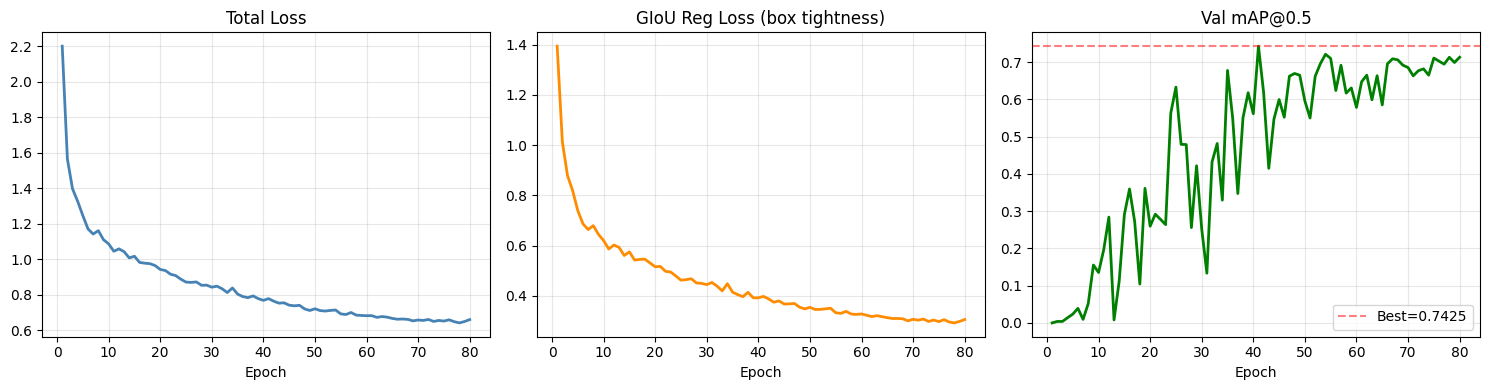

In [30]:

ep   = [r['epoch']    for r in history]
loss = [r['loss']     for r in history]
reg  = [r['reg']      for r in history]
maps = [r['val_ap50'] for r in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ep, loss, color='steelblue', lw=2)
axes[0].set_title('Total Loss'); axes[0].set_xlabel('Epoch')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, reg, color='darkorange', lw=2)
axes[1].set_title('GIoU Reg Loss (box tightness)')
axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)

axes[2].plot(ep, maps, color='green', lw=2)
axes[2].axhline(best_map50, ls='--', color='red', alpha=0.5,
                label=f'Best={best_map50:.4f}')
axes[2].set_title('Val mAP@0.5'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir/'training_curves.png', dpi=120)
plt.show()

In [31]:
if 'test' in loaders:
    ck = torch.load(ckpt_best, map_location=device)
    model.load_state_dict(ck['model'])
    test_ap = compute_map50(model, loaders['test'], device,
                             SCORE_THRESH, NMS_IOU)
    print(f'✅  Test mAP@0.5 = {test_ap:.4f}')
else:
    print('No test/ split.')

✅  Test mAP@0.5 = 0.3161


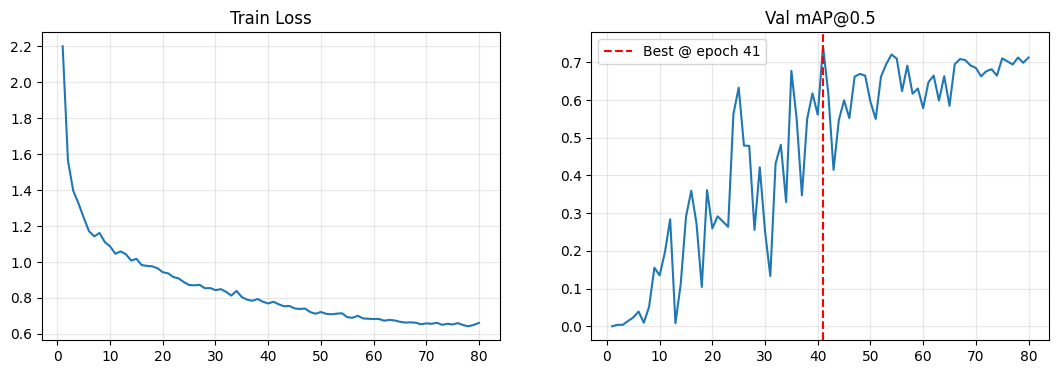

Val mAP peaked at epoch 41 then stayed stable


In [39]:
import json
import matplotlib.pyplot as plt

log = json.load(open(run_dir / 'log.json'))
ep     = [r['epoch']    for r in log]
val_ap = [r['val_ap50'] for r in log]
loss   = [r['loss']     for r in log]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(ep, loss);   ax1.set_title('Train Loss'); ax1.grid(True, alpha=0.3)
ax2.plot(ep, val_ap); ax2.set_title('Val mAP@0.5'); ax2.grid(True, alpha=0.3)

# find where val mAP peaked
best_ep = ep[val_ap.index(max(val_ap))]
ax2.axvline(best_ep, color='red', ls='--', label=f'Best @ epoch {best_ep}')
ax2.legend()
plt.show()
print(f'Val mAP peaked at epoch {best_ep} then {"fell" if val_ap[-1] < max(val_ap)*0.9 else "stayed stable"}')

In [35]:
from infer import PersonDetectorInference

detector = PersonDetectorInference(
    checkpoint_path=str(ckpt_best),
    device=str(device),
    score_thresh=SCORE_THRESH,
    nms_iou=NMS_IOU,
    padding=CROP_PADDING,
)

IMAGE_EXTS  = {'.jpg','.jpeg','.png','.bmp','.webp'}
MIN_BOX_AREA = 0.005
crops_root   = Path(CROPS_DIR)
crops_root.mkdir(parents=True, exist_ok=True)

total_crops = 0

for split in ['train','val','test']:
    img_dir = Path(DATASET_ROOT) / split / 'images'
    if not img_dir.exists():
        print(f'⚠️  {split}/ not found, skipping'); continue

    out_dir = crops_root / split
    out_dir.mkdir(parents=True, exist_ok=True)

    img_paths = sorted(p for p in img_dir.iterdir()
                       if p.suffix.lower() in IMAGE_EXTS)
    csv_rows  = []
    n_crops = n_skip = 0

    print(f'\n── {split} ({len(img_paths)} images) ──')
    pbar = tqdm(img_paths, desc=split)

    for img_path in pbar:
        try:
            image = PILImage.open(img_path).convert('RGB')
        except Exception as e:
            print(f'  skip {img_path.name}: {e}'); continue

        W, H   = image.size
        result = detector.detect_image(image)

        if not result['crops']:
            n_skip += 1; continue

        saved = 0
        for i, (crop, bpx, bnm, score) in enumerate(zip(
                result['crops'], result['boxes_px'],
                result['boxes_norm'], result['scores'])):

            x1,y1,x2,y2 = bpx
            if ((x2-x1)*(y2-y1)) / max(W*H,1) < MIN_BOX_AREA:
                continue

            fname    = f'{img_path.stem}_person{i:02d}.jpg'
            out_path = out_dir / fname
            crop.save(out_path, 'JPEG', quality=95)

            csv_rows.append(dict(
                crop_path=str(out_path), source_img=str(img_path),
                x1_norm=round(bnm[0],6), y1_norm=round(bnm[1],6),
                x2_norm=round(bnm[2],6), y2_norm=round(bnm[3],6),
                x1_px=x1, y1_px=y1, x2_px=x2, y2_px=y2,
                score=round(score,4),
                crop_w=crop.width, crop_h=crop.height,
            ))
            n_crops += 1; saved += 1

        if saved == 0: n_skip += 1
        pbar.set_postfix({'crops': n_crops})

    if csv_rows:
        csv_path = crops_root / f'{split}_manifest.csv'
        with open(csv_path,'w',newline='') as f:
            w = csv.DictWriter(f, fieldnames=csv_rows[0].keys())
            w.writeheader(); w.writerows(csv_rows)
        print(f'  manifest → {csv_path}')

    total_crops += n_crops
    print(f'  ✅  {n_crops} crops  ({n_skip} images with 0 detections)')

print(f'\n🎉  Total crops: {total_crops} → {crops_root}')

[PersonDetector-FCOS] loaded  device=cuda  input=640px

── train (559 images) ──


train:   0%|          | 0/559 [00:00<?, ?it/s]

  manifest → /content/drive/MyDrive/mobilenetv3_step2/person_crops/train_manifest.csv
  ✅  959 crops  (6 images with 0 detections)

── val (111 images) ──


val:   0%|          | 0/111 [00:00<?, ?it/s]

  manifest → /content/drive/MyDrive/mobilenetv3_step2/person_crops/val_manifest.csv
  ✅  138 crops  (5 images with 0 detections)

── test (183 images) ──


test:   0%|          | 0/183 [00:00<?, ?it/s]

  manifest → /content/drive/MyDrive/mobilenetv3_step2/person_crops/test_manifest.csv
  ✅  439 crops  (4 images with 0 detections)

🎉  Total crops: 1536 → /content/drive/MyDrive/mobilenetv3_step2/person_crops


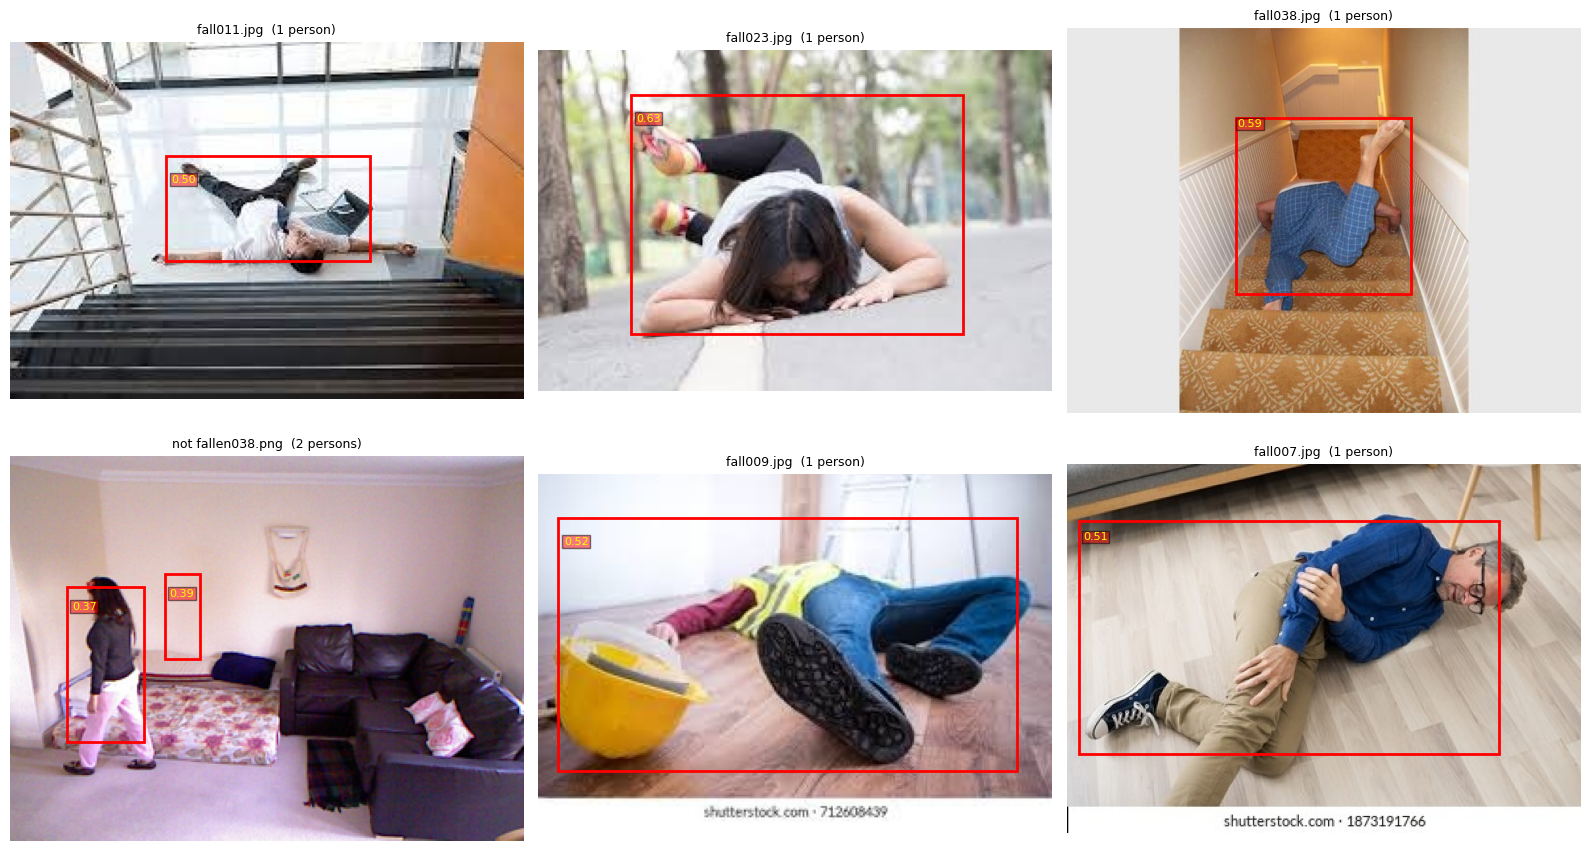

In [36]:


sample_dir = Path(DATASET_ROOT) / 'val' / 'images'
if not sample_dir.exists():
    sample_dir = Path(DATASET_ROOT) / 'train' / 'images'

all_imgs = [p for p in sample_dir.iterdir()
            if p.suffix.lower() in IMAGE_EXTS]
samples  = random.sample(all_imgs, min(6, len(all_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, img_path in zip(axes.flatten(), samples):
    img    = PILImage.open(img_path).convert('RGB')
    result = detector.detect_image(img)
    ax.imshow(img)
    for (x1,y1,x2,y2), score in zip(result['boxes_px'], result['scores']):
        ax.add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='red', facecolor='none'))
        ax.text(x1+3, y1+14, f'{score:.2f}', color='yellow',
                fontsize=8, bbox=dict(facecolor='red',alpha=0.5,pad=1))
    n = len(result['scores'])
    ax.set_title(f'{img_path.name}  ({n} person{"s" if n!=1 else ""})',
                 fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(run_dir/'sample_detections.png', dpi=100)
plt.show()

In [37]:
def count_files(d):
    p = Path(d)
    return sum(1 for f in p.rglob('*.jpg') if f.is_file()) if p.exists() else 0

print('='*55)
print('  OUTPUT SUMMARY')
print('='*55)
print(f'  best.pt              : {ckpt_best}')
print(f'  last.pt              : {ckpt_last}')
print(f'  log.json             : {run_dir}/log.json')
print(f'  training_curves.png  : {run_dir}/training_curves.png')
print(f'  sample_detections.png: {run_dir}/sample_detections.png')
print()
print(f'  Crops root : {CROPS_DIR}')
for s in ["train","val","test"]:
    print(f'    {s:5s}: {count_files(Path(CROPS_DIR)/s)} crops')
print()
print(f'  Best val mAP@0.5 : {best_map50:.4f}')
print('='*55)
print('Model 1 complete — pass crops to Model 2.')

  OUTPUT SUMMARY
  best.pt              : /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1/best.pt
  last.pt              : /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1/last.pt
  log.json             : /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1/log.json
  training_curves.png  : /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1/training_curves.png
  sample_detections.png: /content/drive/MyDrive/mobilenetv3_step2/person_detector_runs/run1/sample_detections.png

  Crops root : /content/drive/MyDrive/mobilenetv3_step2/person_crops
    train: 939 crops
    val  : 138 crops
    test : 439 crops

  Best val mAP@0.5 : 0.7425
Model 1 complete — pass crops to Model 2.


In [40]:
ck = torch.load(ckpt_best, map_location=device)
model.load_state_dict(ck['model'])
model.eval()
print(f'Loaded best.pt  (epoch {ck["epoch"]}  '
      f'best_val_mAP50={ck["best_map50"]:.4f})')

Loaded best.pt  (epoch 41  best_val_mAP50=0.7425)


In [41]:
# ── Full test-set metric collection ─────────────────────────────
# Collects per-detection IoU, TP/FP/FN counts, per-image stats.

IMAGE_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}

def load_gt_boxes(label_path):
    """Load YOLO label → (N,4) cx cy w h tensor."""
    boxes = []
    if label_path and Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                p = line.strip().split()
                if len(p) >= 5:
                    boxes.append(list(map(float, p[1:5])))
    return torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros(0,4)

def cxcywh_to_xyxy(boxes):
    """(N,4) cx cy w h → x1 y1 x2 y2  (normalised)."""
    if boxes.numel() == 0: return boxes
    return torch.stack([
        boxes[:,0]-boxes[:,2]/2,
        boxes[:,1]-boxes[:,3]/2,
        boxes[:,0]+boxes[:,2]/2,
        boxes[:,1]+boxes[:,3]/2,
    ], dim=1)

def run_test_metrics(model, dataset_root, split='test',
                     score_thresh=0.35, nms_iou=0.45,
                     iou_match_thresh=0.5):
    """
    Returns a dict with full test-set metrics + per-image records.
    """
    img_dir = Path(dataset_root) / split / 'images'
    lbl_dir = Path(dataset_root) / split / 'labels'
    img_paths = sorted(p for p in img_dir.iterdir()
                       if p.suffix.lower() in IMAGE_EXTS)

    all_ious        = []   # IoU of every matched TP pred
    all_scores      = []   # (score, is_tp) for mAP
    per_image       = []   # per-image breakdown
    n_gt_total      = 0
    n_tp = n_fp = n_fn = 0

    model.eval()
    from tqdm.notebook import tqdm as tnb

    for img_path in tnb(img_paths, desc=f'Evaluating {split}'):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        gt_cxywh = load_gt_boxes(lbl_path)          # (N,4) norm cxcywh
        gt_xyxy  = cxcywh_to_xyxy(gt_cxywh)         # (N,4) norm xyxy
        n_gt     = gt_xyxy.size(0)
        n_gt_total += n_gt

        # run detector
        img = PILImage.open(img_path).convert('RGB')
        W, H = img.size

        from torchvision.transforms import functional as TF2
        t = TF2.normalize(
            TF2.to_tensor(TF2.resize(img, [INPUT_SIZE, INPUT_SIZE])),
            [0.485,0.456,0.406], [0.229,0.224,0.225]
        ).unsqueeze(0).to(device)

        with torch.no_grad():
            preds = model(t)
            dets  = model.decode(preds, INPUT_SIZE, INPUT_SIZE,
                                 score_thresh=score_thresh, nms_iou=nms_iou)

        pred_boxes  = dets[0]['boxes']    # (K,4) xyxy norm
        pred_scores = dets[0]['scores']   # (K,)
        n_pred      = pred_boxes.size(0)

        img_iou_list  = []
        img_tp = img_fp = img_fn = 0

        if n_pred == 0 and n_gt == 0:
            pass
        elif n_pred == 0:
            img_fn    = n_gt
            n_fn     += n_gt
        elif n_gt == 0:
            img_fp    = n_pred
            n_fp     += n_pred
            for s in pred_scores:
                all_scores.append((s.item(), 0))
        else:
            gt_xyxy_dev = gt_xyxy.to(device)
            iou_mat     = tv_box_iou(pred_boxes, gt_xyxy_dev)  # (K, N)
            matched_gt  = set()

            for ki in pred_scores.argsort(descending=True):
                best_iou, best_j = iou_mat[ki].max(dim=0)
                bv = best_iou.item()
                bj = best_j.item()
                if bv >= iou_match_thresh and bj not in matched_gt:
                    all_scores.append((pred_scores[ki].item(), 1))
                    all_ious.append(bv)
                    img_iou_list.append(bv)
                    matched_gt.add(bj)
                    img_tp += 1
                else:
                    all_scores.append((pred_scores[ki].item(), 0))
                    img_fp += 1

            img_fn  = n_gt - len(matched_gt)
            n_tp   += img_tp
            n_fp   += img_fp
            n_fn   += img_fn

        per_image.append(dict(
            path      = str(img_path),
            n_gt      = n_gt,
            n_pred    = n_pred,
            tp        = img_tp,
            fp        = img_fp,
            fn        = img_fn,
            mean_iou  = float(np.mean(img_iou_list)) if img_iou_list else 0.0,
            gt_cxywh  = gt_cxywh,
            pred_boxes= pred_boxes.cpu(),
            scores    = pred_scores.cpu(),
        ))

    # mAP@0.5
    ap50 = 0.0
    if all_scores:
        all_scores.sort(key=lambda x: -x[0])
        tp_c  = torch.tensor([x[1] for x in all_scores], dtype=torch.float32).cumsum(0)
        fp_c  = (1-torch.tensor([x[1] for x in all_scores], dtype=torch.float32)).cumsum(0)
        prec  = tp_c / (tp_c + fp_c).clamp(1e-6)
        rec   = tp_c / max(n_gt_total, 1)
        ap50  = sum(prec[rec>=t].max().item() if (rec>=t).any() else 0.0
                    for t in torch.linspace(0,1,101)) / 101.0

    precision = n_tp / max(n_tp + n_fp, 1)
    recall    = n_tp / max(n_tp + n_fn, 1)
    f1        = 2*precision*recall / max(precision+recall, 1e-6)
    avg_iou   = float(np.mean(all_ious)) if all_ious else 0.0

    return dict(
        mAP50     = ap50,
        avg_iou   = avg_iou,
        precision = precision,
        recall    = recall,
        f1        = f1,
        n_gt      = n_gt_total,
        n_tp      = n_tp,
        n_fp      = n_fp,
        n_fn      = n_fn,
        all_ious  = all_ious,
        per_image = per_image,
    )

print('Metric function defined ✅')

Metric function defined ✅


In [44]:
# ── Run metrics ─────────────────────────────────────────────────
metrics = run_test_metrics(
    model, DATASET_ROOT, split='test',
    score_thresh=SCORE_THRESH, nms_iou=NMS_IOU,
)

print('\n' + '='*52)
print('  TEST SET METRICS')
print('='*52)
print(f'  mAP @ IoU=0.50        : {metrics["mAP50"]:.4f}')
print(f'  Average IoU (TP only) : {metrics["avg_iou"]:.4f}')
print(f'  Precision             : {metrics["precision"]:.4f}')
print(f'  Recall                : {metrics["recall"]:.4f}')
print(f'  F1 Score              : {metrics["f1"]:.4f}')
print('─'*52)
print(f'  Total GT boxes        : {metrics["n_gt"]}')
print(f'  True  Positives (TP)  : {metrics["n_tp"]}')
print(f'  False Positives (FP)  : {metrics["n_fp"]}  ← ghost detections')
print(f'  False Negatives (FN)  : {metrics["n_fn"]}  ← missed persons')
print('='*52)

Evaluating test:   0%|          | 0/183 [00:00<?, ?it/s]


  TEST SET METRICS
  mAP @ IoU=0.50        : 0.3161
  Average IoU (TP only) : 0.6356
  Precision             : 0.2642
  Recall                : 0.5202
  F1 Score              : 0.3505
────────────────────────────────────────────────────
  Total GT boxes        : 223
  True  Positives (TP)  : 116
  False Positives (FP)  : 323  ← ghost detections
  False Negatives (FN)  : 107  ← missed persons


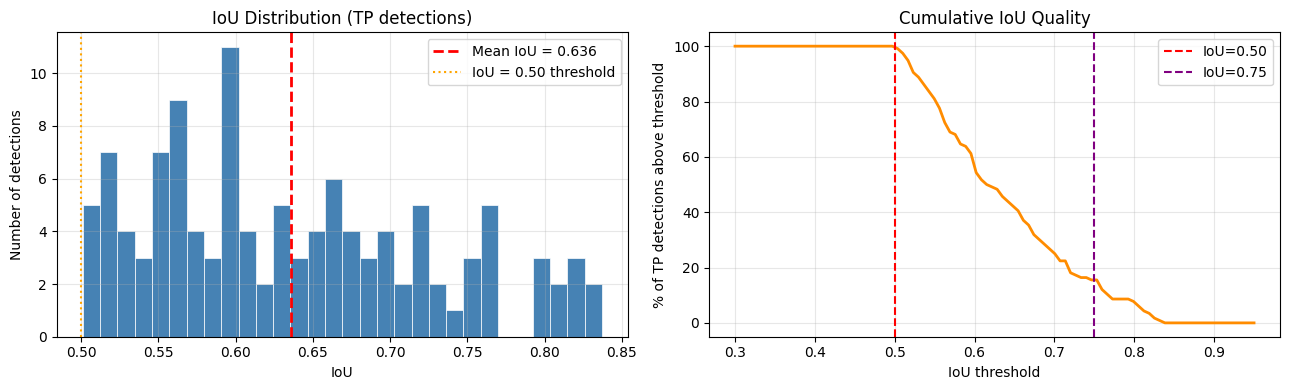

  % boxes IoU > 0.50 : 100.0%
  % boxes IoU > 0.75 : 15.5%
  % boxes IoU > 0.90 : 0.0%


In [45]:
# ── IoU distribution histogram ───────────────────────────────────
ious = metrics['all_ious']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# histogram
axes[0].hist(ious, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(metrics['avg_iou'], color='red', ls='--', lw=2,
                label=f'Mean IoU = {metrics["avg_iou"]:.3f}')
axes[0].axvline(0.5, color='orange', ls=':', lw=1.5, label='IoU = 0.50 threshold')
axes[0].set_xlabel('IoU')
axes[0].set_ylabel('Number of detections')
axes[0].set_title('IoU Distribution (TP detections)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# cumulative % of detections above each IoU threshold
thresholds = np.linspace(0.3, 0.95, 100)
pct_above  = [np.mean(np.array(ious) >= t) * 100 for t in thresholds]
axes[1].plot(thresholds, pct_above, color='darkorange', lw=2)
axes[1].axvline(0.5, color='red', ls='--', lw=1.5, label='IoU=0.50')
axes[1].axvline(0.75, color='purple', ls='--', lw=1.5, label='IoU=0.75')
axes[1].set_xlabel('IoU threshold')
axes[1].set_ylabel('% of TP detections above threshold')
axes[1].set_title('Cumulative IoU Quality')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir / 'iou_distribution.png', dpi=120)
plt.show()
print(f'  % boxes IoU > 0.50 : {np.mean(np.array(ious)>0.50)*100:.1f}%')
print(f'  % boxes IoU > 0.75 : {np.mean(np.array(ious)>0.75)*100:.1f}%')
print(f'  % boxes IoU > 0.90 : {np.mean(np.array(ious)>0.90)*100:.1f}%')

In [46]:
# ── Score threshold sweep ─────────────────────────────────────────
# Finds the best score threshold for this test set.
print('Score threshold sweep (re-runs evaluation at each threshold):')
print(f'{"Thresh":>8}  {"Prec":>7}  {"Recall":>7}  {"F1":>7}  {"AvgIoU":>8}')
print('─' * 48)

best_f1_thresh = SCORE_THRESH
best_f1_val    = 0.0
sweep_results  = []

for thresh in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    r = run_test_metrics(model, DATASET_ROOT, split='test',
                         score_thresh=thresh, nms_iou=NMS_IOU)
    marker = '  ← current' if thresh == SCORE_THRESH else ''
    if r['f1'] > best_f1_val:
        best_f1_val    = r['f1']
        best_f1_thresh = thresh
    sweep_results.append(r)
    print(f'  {thresh:.2f}     {r["precision"]:.4f}   {r["recall"]:.4f}   '
          f'{r["f1"]:.4f}   {r["avg_iou"]:.4f}{marker}')

print(f'\n  ⭐  Best F1 threshold = {best_f1_thresh:.2f}  '
      f'(F1={best_f1_val:.4f})')
print(f'     Set SCORE_THRESH = {best_f1_thresh} for crop export')

Score threshold sweep (re-runs evaluation at each threshold):
  Thresh     Prec   Recall       F1    AvgIoU
────────────────────────────────────────────────


Evaluating test:   0%|          | 0/183 [00:00<?, ?it/s]

  0.15     0.0245   0.7175   0.0474   0.6275


Evaluating test:   0%|          | 0/183 [00:00<?, ?it/s]

  0.20     0.0676   0.6726   0.1228   0.6260


...

  0.50     0.4813   0.3453   0.4021   0.6549


Evaluating test:   0%|          | 0/183 [00:00<?, ?it/s]

  0.55     0.5545   0.2511   0.3457   0.6663


Evaluating test:   0%|          | 0/183 [00:00<?, ?it/s]

  0.60     0.6393   0.1749   0.2746   0.6559

  ⭐  Best F1 threshold = 0.45  (F1=0.4292)
     Set SCORE_THRESH = 0.45 for crop export


Image                                       GT   Pred    TP    FP    FN   MeanIoU
────────────────────────────────────────────────────────────────────────────────
fall_004.jpg                                 1      1     0     1     1    0.0000
fall_006.jpg                                 1      1     0     1     1    0.0000
fall_007.jpg                                 1      3     0     3     1    0.0000
fall_008.jpg                                 1      3     0     3     1    0.0000
fall_009.jpg                                 1      2     0     2     1    0.0000
fall_010.jpg                                 1      2     0     2     1    0.0000
fall_012.jpg                                 1      2     0     2     1    0.0000
fall_013.jpg                                 1      3     0     3     1    0.0000
fall_014.jpg                                 1      1     0     1     1    0.0000
fall_016.jpg                                 1      3     0     3     1    0.0000
fall_021.jpg     

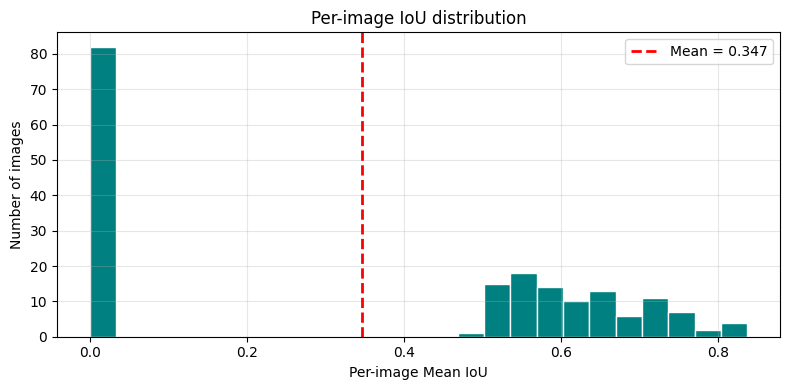

In [47]:
# ── Per-image breakdown ──────────────────────────────────────────
# Shows worst-performing images so you can inspect them.
per_img = metrics['per_image']

# sort by mean_iou ascending (worst first)
per_img_sorted = sorted(
    [p for p in per_img if p['n_gt'] > 0],
    key=lambda x: x['mean_iou']
)

print(f'{'Image':<40}  {'GT':>4}  {'Pred':>5}  {'TP':>4}  {'FP':>4}  {'FN':>4}  {'MeanIoU':>8}')
print('─' * 80)
for r in per_img_sorted[:20]:   # show 20 worst
    name = Path(r['path']).name[:38]
    print(f'{name:<40}  {r["n_gt"]:>4}  {r["n_pred"]:>5}  '
          f'{r["tp"]:>4}  {r["fp"]:>4}  {r["fn"]:>4}  '
          f'{r["mean_iou"]:>8.4f}')

# overall per-image IoU histogram
img_mean_ious = [r['mean_iou'] for r in per_img if r['n_gt'] > 0]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(img_mean_ious, bins=25, color='teal', edgecolor='white')
ax.axvline(np.mean(img_mean_ious), color='red', ls='--', lw=2,
           label=f'Mean = {np.mean(img_mean_ious):.3f}')
ax.set_xlabel('Per-image Mean IoU')
ax.set_ylabel('Number of images')
ax.set_title('Per-image IoU distribution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(run_dir / 'per_image_iou.png', dpi=120)
plt.show()

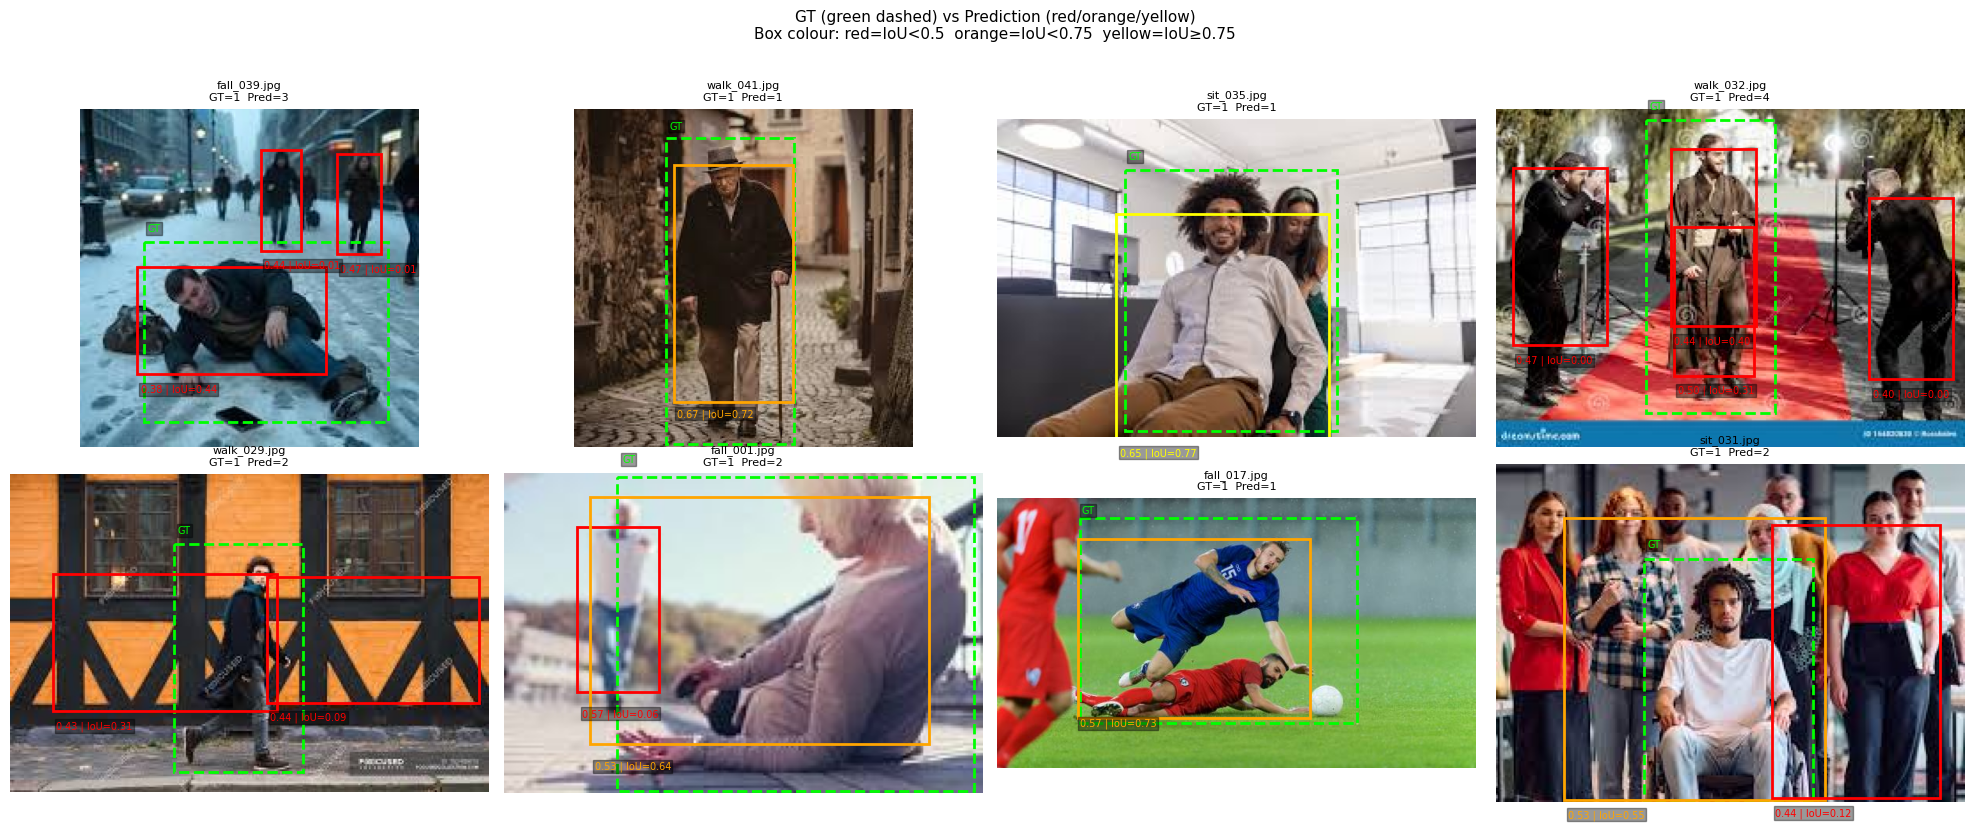

Saved → gt_vs_pred.png


In [48]:
# ── Visual: GT (green) vs Prediction (red) ───────────────────────
# Samples 8 test images and draws both boxes side-by-side.
# Green = ground truth label
# Red   = model prediction
# Numbers = IoU of each matched prediction

def draw_gt_vs_pred(ax, img_path, gt_cxywh, pred_xyxy_norm, scores,
                    iou_mat=None):
    img = PILImage.open(img_path).convert('RGB')
    W, H = img.size
    ax.imshow(img)

    # draw GT boxes — GREEN
    gt_xyxy_norm = cxcywh_to_xyxy(gt_cxywh)
    for box in gt_xyxy_norm:
        x1,y1,x2,y2 = (box * torch.tensor([W,H,W,H])).int().tolist()
        ax.add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1,
            lw=2, edgecolor='lime', facecolor='none', linestyle='--'))
        ax.text(x1+2, y1-6, 'GT', color='lime', fontsize=7,
                bbox=dict(facecolor='black', alpha=0.4, pad=1))

    # draw predicted boxes — RED
    if pred_xyxy_norm.numel() > 0:
        for i, (box, score) in enumerate(zip(pred_xyxy_norm, scores)):
            x1,y1,x2,y2 = (box * torch.tensor([W,H,W,H])).int().tolist()
            # compute best IoU for this pred vs all GT
            best_iou = 0.0
            if gt_cxywh.numel() > 0 and iou_mat is not None:
                best_iou = iou_mat[i].max().item()
            iou_color = 'red' if best_iou < 0.5 else (
                         'orange' if best_iou < 0.75 else 'yellow')
            ax.add_patch(patches.Rectangle(
                (x1,y1), x2-x1, y2-y1,
                lw=2, edgecolor=iou_color, facecolor='none'))
            label = f'{score:.2f} | IoU={best_iou:.2f}'
            ax.text(x1+2, y2+10, label, color=iou_color, fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1))

    n_gt   = gt_cxywh.size(0)
    n_pred = pred_xyxy_norm.size(0) if pred_xyxy_norm.numel() > 0 else 0
    ax.set_title(f'{Path(img_path).name}\nGT={n_gt}  Pred={n_pred}',
                 fontsize=8)
    ax.axis('off')


# pick 8 samples: mix of good and bad IoU images
good = [r for r in per_img if r['mean_iou'] >= 0.7 and r['n_gt'] > 0]
bad  = [r for r in per_img if r['mean_iou'] < 0.5  and r['n_gt'] > 0]
mid  = [r for r in per_img if 0.5 <= r['mean_iou'] < 0.7 and r['n_gt'] > 0]

samples = (random.sample(good, min(3, len(good))) +
           random.sample(mid,  min(2, len(mid)))  +
           random.sample(bad,  min(3, len(bad))))
random.shuffle(samples)
samples = samples[:8]

n_cols = 4
n_rows = (len(samples) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for ax, rec in zip(axes, samples):
    gt_cxywh = rec['gt_cxywh']
    pred_b   = rec['pred_boxes']
    scores   = rec['scores']

    # compute iou matrix for colour coding
    iou_mat = None
    if gt_cxywh.numel() > 0 and pred_b.numel() > 0:
        gt_xyxy  = cxcywh_to_xyxy(gt_cxywh)
        iou_mat  = tv_box_iou(pred_b, gt_xyxy)

    draw_gt_vs_pred(ax, rec['path'], gt_cxywh, pred_b, scores, iou_mat)

for ax in axes[len(samples):]:
    ax.axis('off')

fig.suptitle(
    'GT (green dashed) vs Prediction (red/orange/yellow)\n'
    'Box colour: red=IoU<0.5  orange=IoU<0.75  yellow=IoU≥0.75',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig(run_dir / 'gt_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → gt_vs_pred.png')